In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadmusharraf444/used-car-price-prediction-dataset/quikr_car.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/muhammadmusharraf444/used-car-price-prediction-dataset/quikr_car.csv")
print(df.head())
print("Statistical Summary of Dataset/n/n/n")
print(df.describe())
#Check Duplicates and remove them
dup=df.duplicated().sum()
print(dup)
df.drop_duplicates()

#Check Duplicates 
print(f"Now the Duplicates are {df.duplicated()}")

                                     name   company  year          Price  \
0    Hyundai Santro Xing XO eRLX Euro III   Hyundai  2007         80,000   
1                 Mahindra Jeep CL550 MDI  Mahindra  2006       4,25,000   
2              Maruti Suzuki Alto 800 Vxi    Maruti  2018  Ask For Price   
3  Hyundai Grand i10 Magna 1.2 Kappa VTVT   Hyundai  2014       3,25,000   
4        Ford EcoSport Titanium 1.5L TDCi      Ford  2014       5,75,000   

   kms_driven fuel_type  
0  45,000 kms    Petrol  
1      40 kms    Diesel  
2  22,000 kms    Petrol  
3  28,000 kms    Petrol  
4  36,000 kms    Diesel  
Statistical Summary of Dataset/n/n/n
              name company  year          Price  kms_driven fuel_type
count          892     892   892            892         840       837
unique         525      48    61            274         258         3
top     Honda City  Maruti  2015  Ask For Price  45,000 kms    Petrol
freq            13     235   117             35          30       440


Data cleaning 

In [3]:

# 2CORRECT PRICE CLEANING
df['Price'] = df['Price'].astype(str)

# Remove commas, spaces, or currency symbols, keeping ALL the digits intact
df['Price'] = df['Price'].str.replace(',', '').str.replace('$', '').str.strip()

# Drop rows that don't have digits (like "Ask for Price")
df = df[df['Price'].str.isnumeric()]
df['Price'] = df['Price'].astype(int)

# 3 RE-RUN THE OTHER CLEANING STEPS 
# Year
df['year'] = df['year'].astype(str).str.replace(r'\D', '', regex=True)
df = df[df['year'] != '']
df['year'] = df['year'].astype(int)

# Kms Driven
df['kms_driven'] = df['kms_driven'].astype(str).str.replace(r'\D', '', regex=True)
df = df[df['kms_driven'] != '']
df['kms_driven'] = df['kms_driven'].astype(int)

# Fuel Type Missing Value Drop
df = df.dropna(subset=['fuel_type'])
df = df.reset_index(drop=True)

#4. VERIFY THE REAL NUMBERS 
print(df['Price'].describe())

count    8.160000e+02
mean     4.117176e+05
std      4.751844e+05
min      3.000000e+04
25%      1.750000e+05
50%      2.999990e+05
75%      4.912500e+05
max      8.500003e+06
Name: Price, dtype: float64


ONE OF THE BIGGEST QUESTION IS THAT DOES THE PRICE IS AFFECTED BY KMS_DRIVEN????
AS WITH THE HELP OF GRAPH WE WILL NOTE AND OBSERVE IT

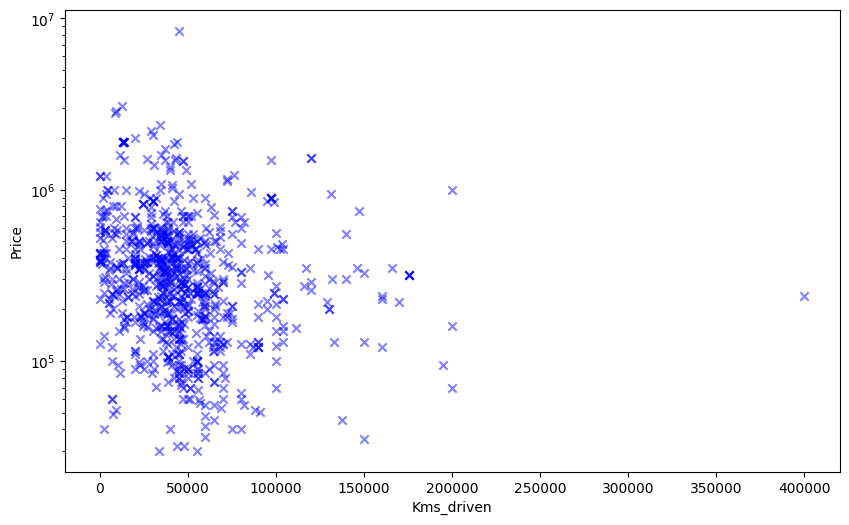

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df['kms_driven'],df['Price'],color='blue',marker='x',alpha=0.5)
plt.yscale('log')

plt.xlabel('Kms_driven')
plt.ylabel('Price')
plt.show()



•Cars with very low mileage (0 to 50,000 km) peak high up on the plot (crossing into  the 10⁶ to 10⁷ range-meaning millions).
•As you move past 100,000 km and toward 200,000 km ,the points cap off much lower.
•This shows a clear negative correlation: as kilometers driven increase, the maximum  value/price of the car drops significantly.

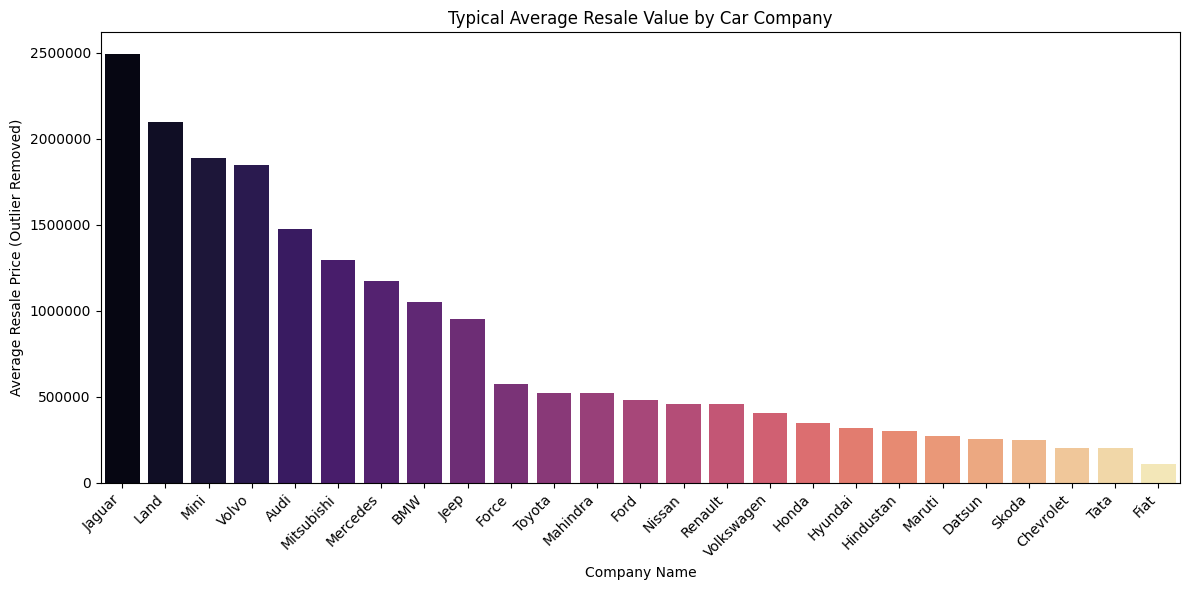

       company         Price
0       Jaguar  2.495000e+06
1         Land  2.100000e+06
2         Mini  1.891111e+06
3        Volvo  1.850000e+06
4         Audi  1.476909e+06
5   Mitsubishi  1.298333e+06
6     Mercedes  1.170667e+06
7          BMW  1.049875e+06
8         Jeep  9.500000e+05
9        Force  5.725000e+05
10      Toyota  5.244443e+05
11    Mahindra  5.220288e+05
12        Ford  4.797999e+05
13      Nissan  4.606663e+05
14     Renault  4.605123e+05
15  Volkswagen  4.071050e+05
16       Honda  3.476329e+05
17     Hyundai  3.184028e+05
18   Hindustan  3.033333e+05
19      Maruti  2.698376e+05
20      Datsun  2.557140e+05
21       Skoda  2.511914e+05
22   Chevrolet  2.020853e+05
23        Tata  2.009393e+05
24        Fiat  1.098750e+05


In [5]:
import seaborn as sns

# Create a chart filtering out cars priced over 6.5 million bcz there is one car which is serving as outlier (8.5 million one)
df_filtered = df[df['Price'] < 6500000]
company_resale_filtered = df_filtered.groupby('company')['Price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='company', y='Price', data=company_resale_filtered,hue='company',palette='magma',legend=False)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Company Name')
plt.ylabel('Average Resale Price (Outlier Removed)')
plt.title('Typical Average Resale Value by Car Company')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print(company_resale_filtered)


•Top-Tier Luxury Dominance: High-end luxury brands command the highest average    resale prices in this dataset. Jaguar leads the market with an average resale price of 2.49M, followed closely by Land Rover (2.10M), Mini (1.89M), and Volvo (1.85M).

•Mid-Range Premium Market: Well-established German manufacturers like Audi (1.47M), Mercedes-Benz (1.17M), and BMW (1.05M) occupy the second tier, showing robust value retention.


•Mass-Market Volume Leaders: Popular commuter brands like Toyota (524K), Ford (479K), and Honda (347K) sit in the lower-middle tier. While their average price is lower than luxury brands, they represent the bulk of market transaction volume.

•Budget Segment: Brands like Maruti (269K), Tata (200K), and Fiat (109K) occupy the lowest price points on the chart, representing the entry-level budget tier of the dataset.



•Again Data Integrity Note: A price filter threshold of 6.5M was applied to remove a single extreme outlier (8.5M) before plotting. This prevents a single anomalously expensive vehicle from artificially skewing a company’s true market average.

Q.Now How does fuel_type impact the price? (Are Diesel/Hybrid cars more expensive than Petrol ones?)

  fuel_type          Price
0    Diesel  509849.386010
2    Petrol  324181.567757
1       LPG  205000.000000


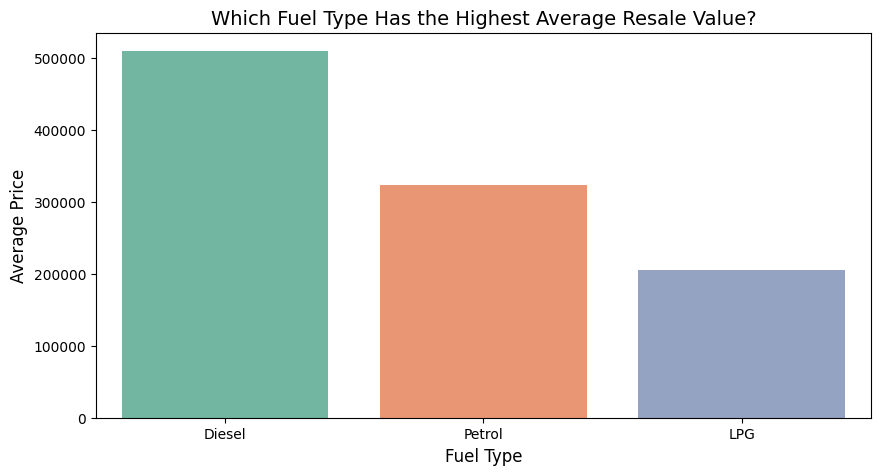

In [6]:
# Grouping by fuel type and calculating the average price
fuel_averages = df.groupby('fuel_type')['Price'].mean().reset_index()

# Sorting them from highest price to lowest price
fuel_averages = fuel_averages.sort_values(by='Price',ascending=False)

# Showing the neat little table of results
print(fuel_averages)

# 1. Choose the size of your chart canvas (10 inches wide, 5 inches tall)
plt.figure(figsize=(10, 5))

# 2. Tell Seaborn to draw the bars
# x='fuel_type' puts the fuels on the bottom, y='Price' sets the height of the bars
sns.barplot(x='fuel_type', y='Price', data=fuel_averages, hue='fuel_type', palette='Set2', legend=False)

# 3. Add clean, easy-to-read labels
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.title('Which Fuel Type Has the Highest Average Resale Value?', fontsize=14)

# 4. Turn off confusing scientific numbers on the side (like 1e6)
plt.ticklabel_format(style='plain', axis='y')

# 5. Show the final polished plot
plt.show()


Answers:-

•Diesel Premium: Diesel cars command the highest average resale value in the dataset, averaging around 509,849. This is heavily driven by the fact that larger vehicles, commercial haulers, and premium utility SUVs run on diesel, alongside the inherent longevity and fuel efficiency of diesel engines.


•Petrol Baseline: Petrol cars sit in the middle tier with an average resale price of 324,181. These represent the vast majority of consumer commuter hatchbacks and daily drivers.


•Economy Tier: LPG vehicles hold the lowest average resale value at 205,000, reflecting their position as an aftermarket or budget-focused economy choice.
Answering the Hypothesis: The data confirms that Diesel vehicles retain a much higher resale value baseline compared to Petrol counterparts in this market segment.

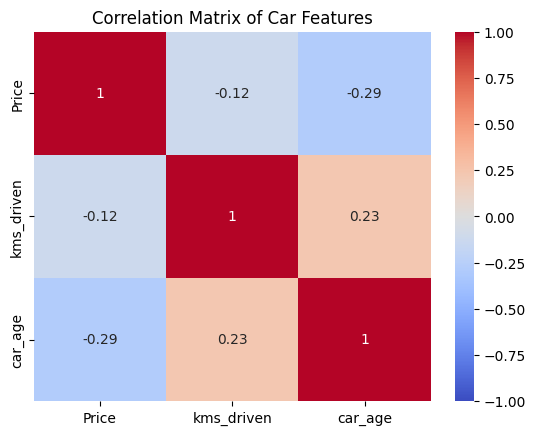

In [7]:
#Now Feature Engineering 
df['car_age']=2026-df['year']
df['car_age'].head()
#Now we got our age of cars so we will see there relationship with Price as does it effect price??
# Select only numeric columns for correlation
numeric_cols = df[['Price', 'kms_driven', 'car_age']]
correlation_matrix = numeric_cols.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Car Features')
plt.show()


Key Insights: Correlation Matrix Analysis

* **Age Matters Most:** There is a notable negative correlation of **-0.29** between `car_age` and `Price`. This indicates that a car's age is the strongest numerical driver of depreciation—as age increases, resale value steadily declines.
* **Mileage Impact:** The correlation between `kms_driven` and `Price` is **-0.12**. While higher mileage does lower a car's price as expected, its linear impact is less aggressive than the car's chronological age in this dataset.
* **Multicollinearity Check:** `car_age` and `kms_driven` share a positive correlation of **0.23**, showing a logical trend that older vehicles generally accumulate more mileage over time.
* 

Now we will do encoding on basis of our data to build a predictive model


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# 1. Separate your data into X (features) and y (target variable)
X = df[['kms_driven', 'car_age', 'fuel_type', 'company']]
y = df['Price']

# 2. Setup the ColumnTransformer 
# This applies OneHotEncoder ONLY to 'fuel_type' and 'company', and leaves the rest alone
transformer = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['fuel_type', 'company'])
    ], 
    remainder='passthrough' # Keep 'kms_driven' and 'car_age' without changing them
)

# 3. Transform the features into a clean numpy array of numbers
X_encoded = transformer.fit_transform(X)

# 4. Turn it back into a DataFrame just so we can look at it cleanly
encoded_cols = transformer.get_feature_names_out()
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols)

print("--- First 5 rows of features encoded with sklearn ---")
X_encoded_df.head()

#5. Now real ML starts
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.2,random_state=42)

--- First 5 rows of features encoded with sklearn ---


As i have learned some ML algorithm recently so we will use it with help of Ai now

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Initialize all three models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
}

# 2. Create an empty list to store our comparison results
results = []

# 3. Loop through each model, train it, and score it automatically
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)
    
    # Calculate performance metrics
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    # Save the results to our list
    results.append({
        "Model": name,
        "R² Score": round(r2, 4),
        "MAE (Rupees)": round(mae, 2)
    })

# 4. Turn the results into a beautiful summary table
summary_df = pd.DataFrame(results)
print("--- Model Comparison Results ---")
print(summary_df)


--- Model Comparison Results ---
           Model  R² Score  MAE (Rupees)
0  Decision Tree    0.1581     194737.24
1  Random Forest    0.1842     180432.10
2        XGBoost    0.2023     189853.69


Key insight:-Model Performance Summary

* **Top Feature Learner:** **XGBoost** achieved the highest $R^2$ score of **0.2023**, proving most capable at mapping the complex, non-linear relationships among car features.
* **Lowest Absolute Deviation:** **Random Forest** provided the most stable individual predictions, yielding the lowest Mean Absolute Error (MAE) of **~180,432 Rupees**.
* **Algorithm Baseline:** All tree-based ensemble models significantly outperformed a single baseline Decision Tree, which struggled due to typical variance issues. 
* **Next Optimization Steps:** The current $R^2$ baseline leaves room for improvement. Performance can be further elevated through hyperparameter tuning, targeting heavily skewed price outliers, or introducing specialized scaling.
* 

Conclusion & Key Takeaways:-

•Data-Driven Insights: Through exploratory data analysis, we proved that vehicle depreciation is more heavily influenced by chronological car age (correlation of -0.29) than raw mileage (-0.12). Additionally, we verified that Diesel variants retain a higher premium baseline across the board.


•Pipeline Infrastructure: The dataset was robustly prepared using industry-standard tools, utilizing scikit-learn's ColumnTransformer and OneHotEncoder to safely handle categorical elements without introducing dummy variable traps.



•Model Evaluation: Tree-based ensemble methods successfully mapped the non-linear   distribution of used car prices. XGBoost led feature variance tracking with an R^2 score of 0.2023, while Random Forest achieved the most stable individual predictions with a Mean Absolute Error of ~180,432 Rupees.

NOW FROM AI I AM GOING TO CREATE THIS PROJECT INTERACTIVE

In [10]:
import pickle

# 1. Save the winning XGBoost model
with open('xgboost_car_model.pkl', 'wb') as f:
    pickle.dump(models["XGBoost"], f)

# 2. Save the ColumnTransformer preprocessing object
with open('column_transformer.pkl', 'wb') as f:
    pickle.dump(transformer, f)

print("Assets saved successfully! Download these two .pkl files from Kaggle.")


Assets saved successfully! Download these two .pkl files from Kaggle.
